<a href="https://colab.research.google.com/github/prabhusanika24/CSL701-ce37_Machine-Learning-Lab/blob/main/Experiment_6_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name: Sanika Janardan Prabhu
Rollno:CE37

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


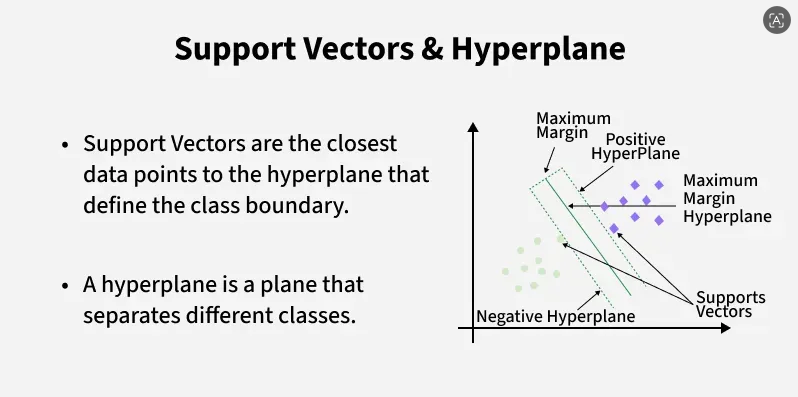
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset (using Seaborn's built-in Iris dataset for convenience)
iris_df = sns.load_dataset('iris')
print("Dataset loaded successfully!")

Dataset loaded successfully!


# Task 2: Explore the Dataset

In [ ]:
print("--- First 5 Rows ---")
print(iris_df.head())

print("\n--- Dataset Info ---")
print(iris_df.info())

print("\n--- Target Distribution ---")
print(iris_df['species'].value_counts())

--- First 5 Rows ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

--- Target Distribution ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Separate features and target label
X = iris_df.drop('species', axis=1)
y = iris_df['species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# Create and train Linear SVM classifier
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)
print("Model training complete.")

Model training complete.


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Accuracy: 100.00%



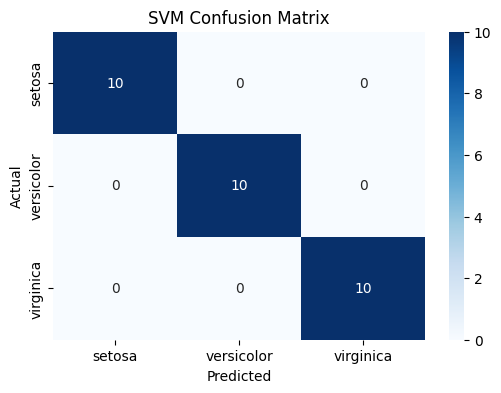

--- SVM Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Calculate Accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm * 100:.2f}%\n")

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

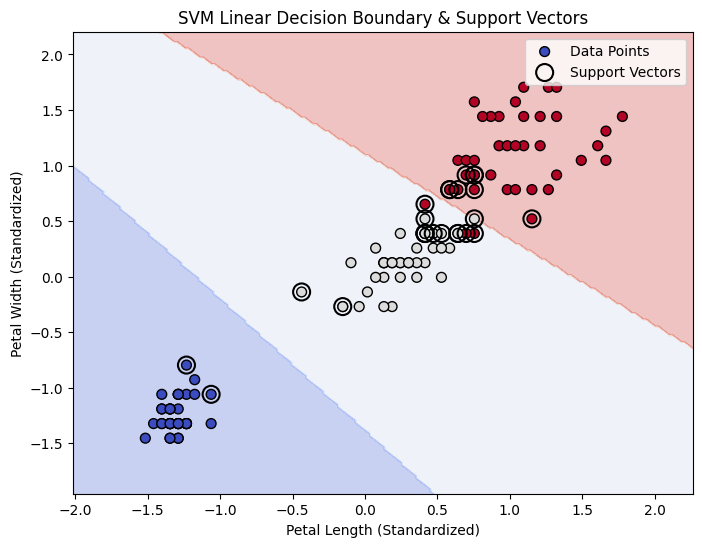

In [ ]:
# 1. Select only Petal Length and Petal Width
X_2d = iris_df[['petal_length', 'petal_width']]
y_2d = iris_df['species']

# Encode labels to numerical values for easier plotting
y_2d_encoded = y_2d.astype('category').cat.codes

# 2. Split 2D Data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d_encoded, test_size=0.2, random_state=42, stratify=y_2d_encoded
)

# 3. Scale 2D Data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# 4. Train 2D SVM Model
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Helper function to plot decision boundaries
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 0.5, x.max() + 0.5
    y_min, y_max = y.min() - 0.5, y.max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

# 5. Plot SVM Decision Boundary & Support Vectors
xx, yy = make_meshgrid(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1])
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d,
            cmap=plt.cm.coolwarm, edgecolors='k', s=50, label='Data Points')

# Highlight Support Vectors
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1], s=150,
            facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.title('SVM Linear Decision Boundary & Support Vectors')
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

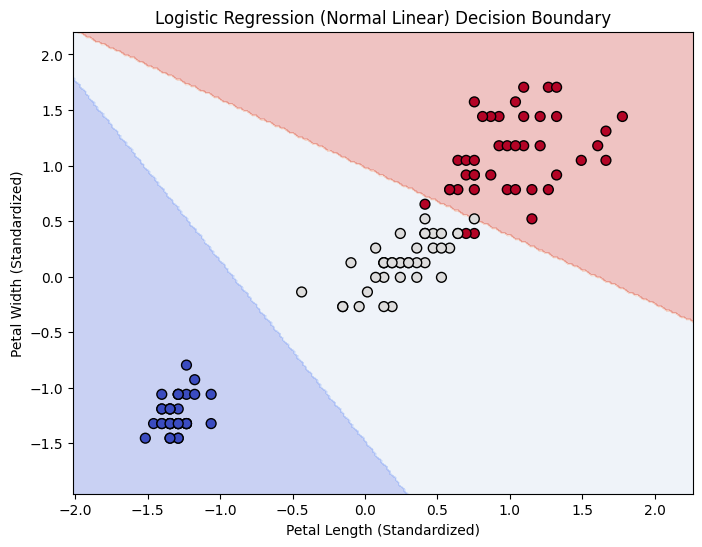

In [ ]:
# Train Logistic Regression on the same 2D scaled data
lr_2d = LogisticRegression(random_state=42)
lr_2d.fit(X_train_2d_scaled, y_train_2d)

# Plot Logistic Regression Decision Boundary
Z_lr = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_lr, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d,
            cmap=plt.cm.coolwarm, edgecolors='k', s=50)

plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.title('Logistic Regression (Normal Linear) Decision Boundary')
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

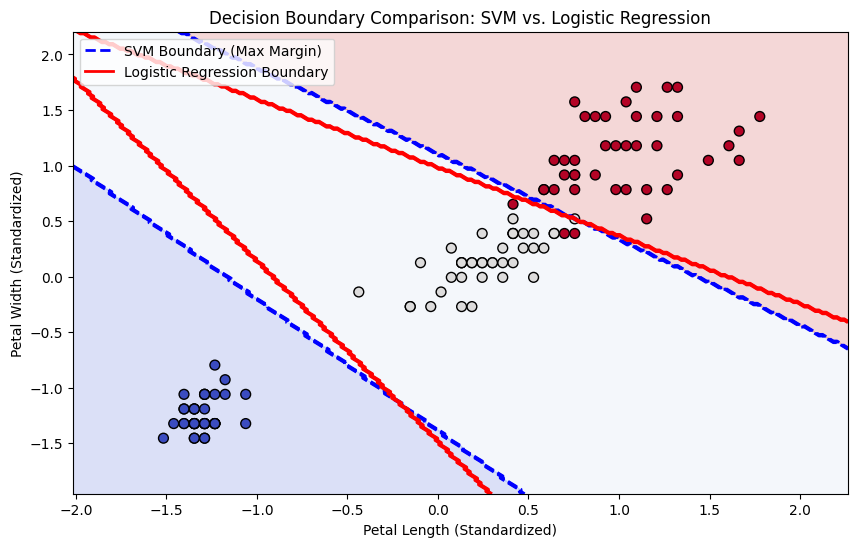

In [ ]:
plt.figure(figsize=(10, 6))

# Background color shading for SVM classes
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)

# Draw decision lines for SVM vs. Logistic Regression
cs_svm = plt.contour(xx, yy, Z, colors='blue', linewidths=2, linestyles='--')
cs_lr = plt.contour(xx, yy, Z_lr, colors='red', linewidths=2, linestyles='-')

plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], c=y_train_2d,
            cmap=plt.cm.coolwarm, edgecolors='k', s=50)

# Custom legend for contour lines
from matplotlib.lines import Line2D

# Create proxy artists for the legend entries
line_svm = Line2D([0], [0], color='blue', linewidth=2, linestyle='--')
line_lr = Line2D([0], [0], color='red', linewidth=2, linestyle='-')

lines = [line_svm, line_lr]
labels = ['SVM Boundary (Max Margin)', 'Logistic Regression Boundary']
plt.legend(lines, labels, loc='upper left')

plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.title('Decision Boundary Comparison: SVM vs. Logistic Regression')
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
# Predictions on 2D test set
y_pred_svm_2d = svm_2d.predict(X_test_2d_scaled)
y_pred_lr_2d = lr_2d.predict(X_test_2d_scaled)

print("=== 2-Feature Performance Comparison ===")
print(f"SVM Accuracy: {accuracy_score(y_test_2d, y_pred_svm_2d)*100:.2f}%")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_2d, y_pred_lr_2d)*100:.2f}%\n")

print("--- SVM Classification Report (2D) ---")
print(classification_report(y_test_2d, y_pred_svm_2d))

print("--- Logistic Regression Classification Report (2D) ---")
print(classification_report(y_test_2d, y_pred_lr_2d))

=== 2-Feature Performance Comparison ===
SVM Accuracy: 93.33%
Logistic Regression Accuracy: 93.33%

--- SVM Classification Report (2D) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

--- Logistic Regression Classification Report (2D) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.